In [1]:
import numpy as np
import matplotlib.pylab as plt
import time
import math

from mgdraw_output_reader_NOVO_v03 import DetectionDataStorage

primaries_per_spawn = 1.0e7
number_of_files = 100
number_of_primaries = primaries_per_spawn * number_of_files

beam_current = 2.0 # nA

Script will make Figure 4 in manuscript 1. 

Assumes that gamma_hits.txt and neutron_hits.txt files have been made beforehand

Script will build triple coincidence gamma events and double coincidence neutron events and plot layer importance for each

Flow:
    - Build events per spot per patient
    - Save the number of events in a numpy array
    - Plot

In [2]:
def load_hits(main_PATH):

    from hit_txt_file_reader_v01 import collect_txt_data

    files = {"spot1": None, "spot2": None, "spot3": None, "spot4": None, "spot5": None,
            "spot6": None, "spot7": None, "spot8": None, "spot9": None, "spot10": None}

    m = 0
    for spot in files:
        m += 1

        newPath = main_PATH + rf"\Results_spot_{m}"
        print(f"Spot {m}:")

        # Importing gamma_hits
        print("Gamma hits")
        gamma_hits = np.array(collect_txt_data(newPath + rf"\gamma_hits.txt"))

        # Importing neutron_hits
        print("Neutron hits")
        neutron_hits = np.array(collect_txt_data(newPath + rf"\neutron_hits.txt"))

        files[spot] = [gamma_hits, neutron_hits]

    return files

In [90]:
# Taken from DetectionDataStorage from mgdraw_output_reader_NOVO_v03.py
def event_builder(gamma_hits, neutron_hits):
    """
    Will sort self.gamma_hits() and self.neutron_hits() to construct:
    1) self.gamma_events() and self.neutron_events() 

        structure: np.array([
        [[hit1], [hit2], [hit3]],
        [[hit1]],
        [[hit1], [hit2], [hit3], [hit4]]
        ])
    2) self.double_gamma_events, self.triple_gamma_events, self.double_neutron_events, self.triple_neutron_events

        structure double events: np.array([
        [[hit1], [hit2]],
        [[hit1], [hit2]],
        [[hit1], [hit2]]
        ])

        structure triple events: np.array([
        [[hit1], [hit2], [hit3]],
        [[hit1], [hit2], [hit3]],
        [[hit1], [hit2], [hit3]]
        ])

    Returns the number of gamma events and neutron events with coincidences [[1+, 2+, 3+], [1+ ,2+, 3+]], respectively
    """

    # 1) Construct events from hits
    # Gammas
    gamma_events = _event_builder(gamma_hits)
    print("Event summary for gammas:")
    _count_hits_per_event(gamma_events)

    # Neutrons
    neutron_events = _event_builder(neutron_hits)
    print("Event summary for neutrons:")
    _count_hits_per_event(neutron_events)

    # 2) Filter out double/triple events
    # Sorting out double and triple gamma/neutron events

    # Gammas
    double_gamma_events = [event[0:2] for event in gamma_events if len(event) >= 2]
    triple_gamma_events = [event[0:3] for event in gamma_events if len(event) >= 3]

    # Neutrons
    double_neutron_events = [event[0:2] for event in neutron_events if len(event) >= 2]

    return [double_gamma_events, triple_gamma_events, double_neutron_events]


def _event_builder(hit_array):
    """
    Helper function for event_builder
    Inputs: hit array, i.e. self.gamma_hits or self.neutron_hits
    Output: event array, self.gamma_events or self.neutron_events
    """

    event = []  #[[hit1], [hit2], [hit3], ..., [hitN]]
    particle_events = []    # [[[hit1], [hit2], [hit3]], [[hit1], [hit2]], ...] # Final event list, i.e. self.gamma_events or self.neutron_events
    event_ID = [0, 0.0, 0.0, 0.0]   # [NCASE, prodX, prodY, prodZ], ID to sort hits into the same event

    for hit in hit_array:
        # A change in event_ID means that there is a new event
        if event_ID != [hit[1], hit[15], hit[16], hit[17]]:

            # Add the event if it is not the beginning event
            if event_ID != [0, 0.0, 0.0, 0.0]:
                particle_events.append(event)

            # Reset event
            event = [hit]
            event_ID = [hit[1], hit[15], hit[16], hit[17]]

        else:
            event.append(hit)

    # Add the final event
    particle_events.append(event)

    return particle_events

def _count_hits_per_event(event_array):
    """
    Helper function for event_builder. Will summarise the number of hits in events
    Input: event array, i.e. self.gamma_events or self.neutron_events
    Output: print statements about number of hits per event and their counts, i.e. 1 hit : 50203, 2 hits : 4120, 3 hits : 120
    """

    # Collect the number of hits per event
    event_chain = []
    for event in event_array:
        event_chain.append(len(event))

    # Convert to numpy and counting how many events with 1 hit, 2 hits, 3 hits etc.
    event_chain = np.array(event_chain)
    chain_lengths, chain_lengths_counts = np.unique(event_chain, return_counts=True)

    for chain_length, chain_length_count in zip(chain_lengths, chain_lengths_counts):
        if chain_length == 1:
            print(f" {chain_length} hit : {chain_length_count}")
        else:
            print(f" {chain_length} hits : {chain_length_count}")

In [91]:
def load_and_build_events(PATH):

    files = load_hits(PATH)

    for spot in files:
        gamma_hits = np.transpose(files[spot][0])
        neutron_hits = np.transpose(files[spot][1])
        double_gamma_events, triple_gamma_events, double_neutron_events = event_builder(gamma_hits, neutron_hits)

        files[spot] = [double_gamma_events, triple_gamma_events, double_neutron_events]

    return files

In [92]:
# Container of number of 2FNs and 3PGs
both_events = {"brain": None, "HNC": None, "lung": None, "prostate": None}


# Pediatric brain
brain_energies = [120.239, 112.948, 109.551, 106.152, 99.65, 93.544, 87.635, 82.123, 76.909, 71.993]
brain_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Brain_Hv14\270_degree"
both_events["brain"] = load_and_build_events(brain_PATH)


# HNC
HNC_energies = [134.006, 126.327, 119.041, 111.849, 105.052, 98.649, 92.643, 86.733, 81.321, 76.106]
HNC_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_HNC_05\AntObl_L_G80"
both_events["HNC"] = load_and_build_events(HNC_PATH)


# Lung
lung_energies = [180.740, 169.121, 158.789, 149.843, 140.982, 132.012, 123.633, 115.546, 108.051, 100.751]
lung_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Lung_04\Beam_1"
both_events["lung"] = load_and_build_events(lung_PATH)


# Prostate
prostate_energies = [198, 195, 192, 189, 186, 183, 180, 177, 174, 171]
prostate_PATH = r"C:\Users\sathu8821\OneDrive - University of Bergen\NOVO\Studie 1\Pasienter\Anon_Prostate_01_2field\270"
both_events["prostate"] = load_and_build_events(prostate_PATH)

Spot 1:
Gamma hits
Neutron hits
Spot 2:
Gamma hits
Neutron hits
Spot 3:
Gamma hits
Neutron hits
Spot 4:
Gamma hits
Neutron hits
Spot 5:
Gamma hits
Neutron hits
Spot 6:
Gamma hits
Neutron hits
Spot 7:
Gamma hits
Neutron hits
Spot 8:
Gamma hits
Neutron hits
Spot 9:
Gamma hits
Neutron hits
Spot 10:
Gamma hits
Neutron hits
Event summary for gammas:
 1 hit : 294933
 2 hits : 37040
 3 hits : 4883
 4 hits : 699
 5 hits : 73
 6 hits : 5
 7 hits : 3
Event summary for neutrons:
 1 hit : 137021
 2 hits : 16245
 3 hits : 1375
 4 hits : 84
 5 hits : 2
Event summary for gammas:
 1 hit : 267979
 2 hits : 33602
 3 hits : 4510
 4 hits : 651
 5 hits : 63
 6 hits : 6
 7 hits : 1
Event summary for neutrons:
 1 hit : 124193
 2 hits : 15008
 3 hits : 1280
 4 hits : 77
 5 hits : 4
 6 hits : 1
Event summary for gammas:
 1 hit : 253569
 2 hits : 31680
 3 hits : 4251
 4 hits : 574
 5 hits : 75
 6 hits : 9
Event summary for neutrons:
 1 hit : 117115
 2 hits : 14296
 3 hits : 1281
 4 hits : 78
Event summary for g

Layer combinations (Only use one example patient)

Original code from NOVO2.ipynb

Building region lists

In [93]:
patient = "HNC"
spot = 1

double_gamma_events, triple_gamma_events, double_neutron_events = both_events[patient][f"spot{spot}"]

# Double gammas
double_gamma_regions = [] # np.array([[1, 2], [3, 2], [30, 34], ..., [1, 3]])

for event in double_gamma_events:
    region1 = event[0][12]
    region2 = event[1][12]

    double_gamma_regions.append([region1, region2])

double_gamma_regions = np.array(double_gamma_regions)
double_gamma_events = None # Purge variable from memory

# Triple gammas
triple_gamma_regions = [] # np.array([[1, 2, 3], [3, 2, 9], [30, 34, 38], ..., [1, 2, 3]])

for event in triple_gamma_events:
    region1 = event[0][12]
    region2 = event[1][12]
    region3 = event[2][12]

    triple_gamma_regions.append([region1, region2, region3])

triple_gamma_regions = np.array(triple_gamma_regions)
triple_gamma_events = None # Remove variable from memory

# Double neutrons
double_neutron_regions = [] # np.array([[1, 2], [3, 2], [30, 34], ..., [1, 3]])

for event in double_neutron_events:
    region1 = event[0][12]
    region2 = event[1][12]

    double_neutron_regions.append([region1, region2])

double_neutron_regions = np.array(double_neutron_regions)
double_neutron_events = None   # Remove variable from memory

In [94]:
# Test first for HNC
# Plan:
#   X-axis: Energies used
#   Y-axis: Scatter direction (percentage of scatters going to the same or a deeper layer [add clause here])
#   Plots: 
#       Gamma Hit 1 -> Hit 2
#       Gamma Hit 2 -> Hit 3 
#       Neutron Hit 1 -> Hit 2

scatter_direction_distributions = {"brain": None, "HNC": None, "lung": None, "prostate": None}

def decide_scatter_direction_percentage(hit1_regions, hit2_regions, same_layer_OK=True):

    num_forward_scatter = 0
    # Region to layer: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    for hit1_region, hit2_region in zip(hit1_regions, hit2_regions):
        hit1_layer = int((hit1_region - 1)/4) + 1
        hit2_layer = int((hit2_region - 1)/4) + 1

        if hit2_layer >= hit1_layer:
            if hit2_layer == hit1_layer and same_layer_OK is False:
                continue
        
            num_forward_scatter += 1
        
    return round(100 * (num_forward_scatter / hit1_regions.shape[0]), 1)

In [95]:
# Plotting zigzag line for seperating forward scatters vs backscatters
# Code from Copilot

# Parameters
zz_step = 4
zz_max_val = 47

zz_x_coords = [0]
zz_y_coords = [0]

zz_x, zz_y = 0, -1

# Build zigzag
while zz_x < zz_max_val or zz_y < zz_max_val:
    # Go up
    if zz_y < zz_max_val:
        zz_y = min(zz_y + zz_step, zz_max_val)
        zz_x_coords.append(zz_x)
        zz_y_coords.append(zz_y)
    
    # Go right
    if zz_x < zz_max_val:
        zz_x = min(zz_x + zz_step, zz_max_val)
        zz_x_coords.append(zz_x)
        zz_y_coords.append(zz_y)


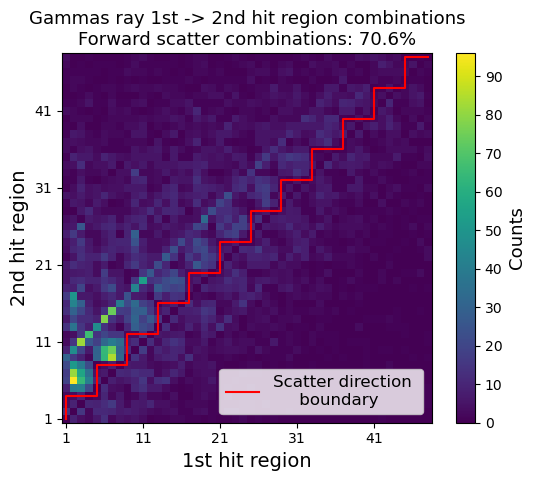

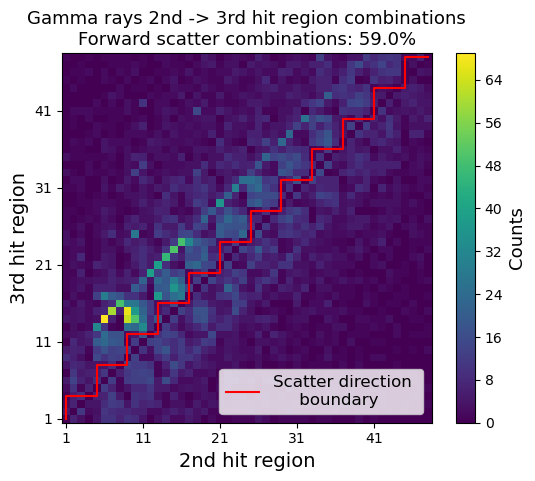

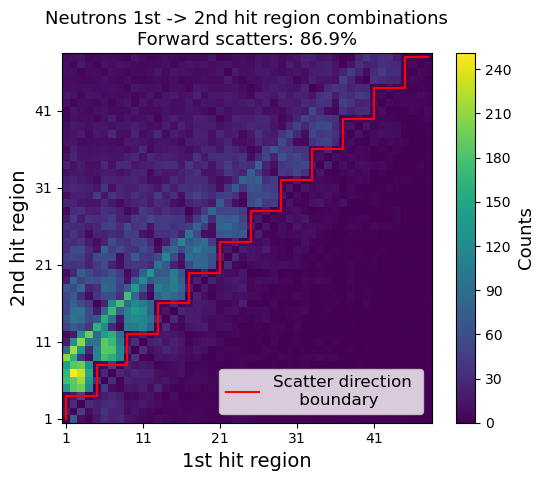

In [96]:
from matplotlib import ticker
from matplotlib.ticker import FuncFormatter
X = np.linspace(1, 48, num=48)

# Gamma region 1 to region 2
gamma_hit_distribution1 = np.zeros((48, 48))

# Connection between first hit and second hit
regions1 = triple_gamma_regions[:, 0]
regions2 = triple_gamma_regions[:, 1]

for index in range(len(regions1)):
    region1 = int(regions1[index])
    region2 = int(regions2[index])

    gamma_hit_distribution1[region1 - 1, region2 - 1] += 1

plt.figure()
image_gamma_12 = plt.imshow(gamma_hit_distribution1.T, cmap="viridis", origin="lower")
plt.plot(zz_x_coords, zz_y_coords, color="red", label="Scatter direction \n     boundary")
plt.ylabel("2nd hit region", fontsize=14)
plt.xlabel("1st hit region", fontsize=14)
#plt.xticks([0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44])
#plt.title(f"Gammas ray 1st -> 2nd hit region combinations\nPatient: {patient}, spot: {spot}, forward scatters: {decide_scatter_direction_percentage(regions1, regions2, same_layer_OK=False)}%")
plt.title(f"Gammas ray 1st -> 2nd hit region combinations\nForward scatter combinations: {decide_scatter_direction_percentage(regions1, regions2, same_layer_OK=False)}%", fontsize=13)


plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)+1}"))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(y)+1}"))

cbar_g12 = plt.colorbar(image_gamma_12, label="Counts")
cbar_g12.locator = ticker.MaxNLocator(integer=True)
cbar_g12.set_label("Counts", fontsize=13)
cbar_g12.update_ticks()

plt.legend(loc="lower right", fontsize=12)

# Gamma region 2 to region 3
gamma_hit_distribution2 = np.zeros((48, 48))

# Connection between first hit and second hit
regions3 = triple_gamma_regions[:, 2]

for index in range(len(regions2)):
    region2 = int(regions2[index])
    region3 = int(regions3[index])
    gamma_hit_distribution2[region2 - 1, region3 - 1] += 1

plt.figure()
image_gamma_23 = plt.imshow(gamma_hit_distribution2.T, cmap="viridis", origin="lower")
plt.plot(zz_x_coords, zz_y_coords, color="red", label="Scatter direction \n     boundary")
plt.ylabel("3rd hit region", fontsize=14)
plt.xlabel("2nd hit region", fontsize=14)
#plt.title(f"Gamma rays 2nd -> 3rd hit region combinations\nPatient: {patient}, spot: {spot}, forward scatters: {decide_scatter_direction_percentage(regions2, regions3, same_layer_OK=False)}%")
plt.title(f"Gamma rays 2nd -> 3rd hit region combinations\nForward scatter combinations: {decide_scatter_direction_percentage(regions2, regions3, same_layer_OK=False)}%", fontsize=13)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)+1}"))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(y)+1}"))

cbar_g23 = plt.colorbar(image_gamma_23, label="Counts")
cbar_g23.locator = ticker.MaxNLocator(integer=True)
cbar_g23.set_label("Counts", fontsize=13)
cbar_g23.update_ticks()

plt.legend(loc="lower right", fontsize=12)

#plt.figure()
#plt.hist(regions1, bins=48, histtype="step", color="red", label="Region1", ls="-")
#plt.hist(regions2, bins=48, histtype="step", color="green", label="Region2", ls="--")
#plt.hist(regions3, bins=48, histtype="step", color="blue", label="Region3", ls="-.")
#plt.legend()

# Neutron

# Neutron region 1 to region 2
neutron_hit_distribution1 = np.zeros((48, 48))

# Connection between first hit and second hit
regions1 = double_neutron_regions[:, 0]
regions2 = double_neutron_regions[:, 1]

for index in range(len(regions1)):
    region1 = int(regions1[index])
    region2 = int(regions2[index])
    layer1 = int((region1 - 1) / 4)
    layer2 = int((region2 - 1) / 4)

    neutron_hit_distribution1[region1 - 1, region2 - 1] += 1

plt.figure()
image_neutron_12 = plt.imshow(neutron_hit_distribution1.T, cmap="viridis", origin="lower")
plt.plot(zz_x_coords, zz_y_coords, color="red", label="Scatter direction \n     boundary")
plt.ylabel("2nd hit region", fontsize=14)
plt.xlabel("1st hit region", fontsize=14)
#plt.title(f"Neutrons 1st -> 2nd hit region combinations\nPatient: {patient}, spot: {spot}, forward scatters: {decide_scatter_direction_percentage(regions1, regions2, same_layer_OK=False)}%")
plt.title(f"Neutrons 1st -> 2nd hit region combinations\nForward scatters: {decide_scatter_direction_percentage(regions1, regions2, same_layer_OK=False)}%", fontsize=13)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)+1}"))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(y)+1}"))

cbar_n12 = plt.colorbar(image_neutron_12, label="Counts")
cbar_n12.locator = ticker.MaxNLocator(integer=True)
cbar_n12.set_label("Counts", fontsize=13)
cbar_n12.update_ticks()

plt.legend(loc="lower right", fontsize=12)

#plt.figure()
#plt.hist(regions1, bins=48, histtype="step", color="red", label="Region1", ls="-")
#plt.hist(regions2, bins=48, histtype="step", color="green", label="Region2", ls="--")
#plt.legend()

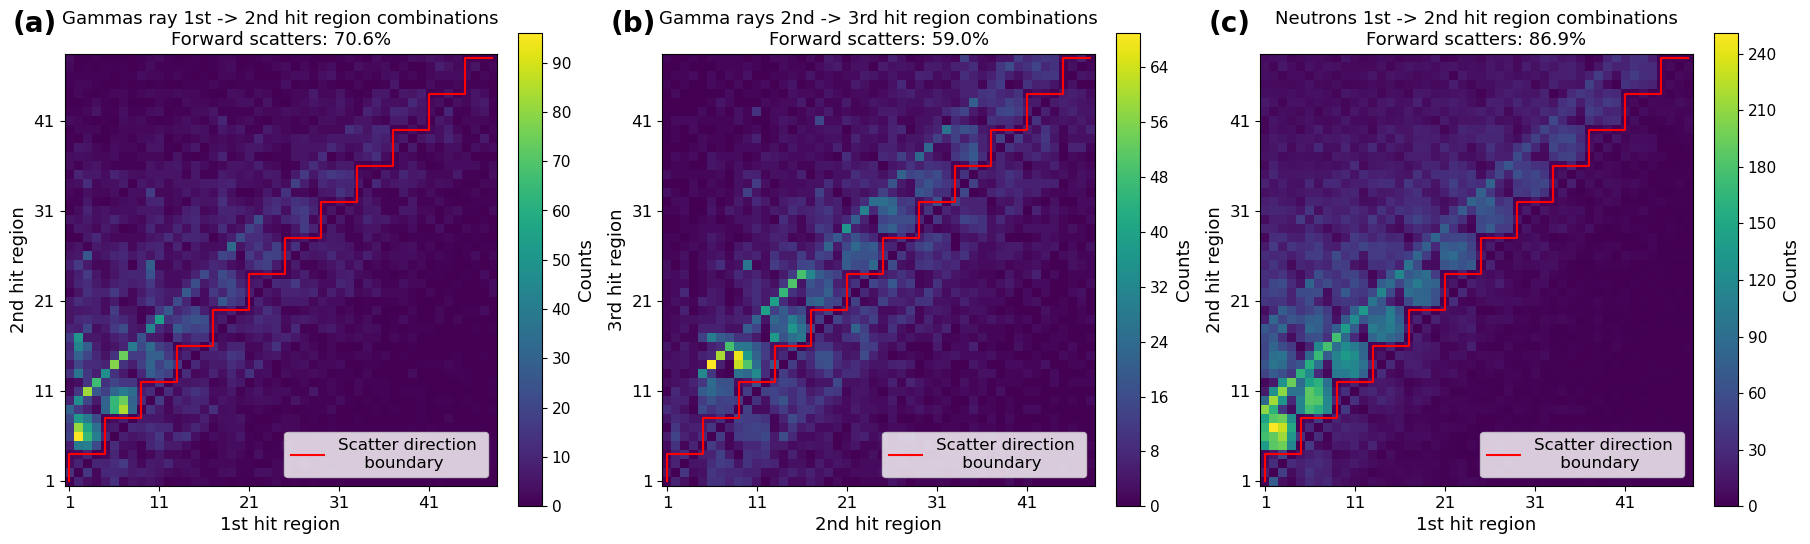

In [ ]:
# Place all plots in the same plot!

from matplotlib import ticker
from matplotlib.ticker import FuncFormatter
X = np.linspace(1, 48, num=48)

fig, axs = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# Gamma region 1 to region 2
gamma_hit_distribution1 = np.zeros((48, 48))

# Connection between first hit and second hit
regions1 = triple_gamma_regions[:, 0]
regions2 = triple_gamma_regions[:, 1]

for index in range(len(regions1)):
    region1 = int(regions1[index])
    region2 = int(regions2[index])

    gamma_hit_distribution1[region1 - 1, region2 - 1] += 1

image_gamma_12 = axs[0].imshow(gamma_hit_distribution1.T, cmap="viridis", origin="lower")
axs[0].plot(zz_x_coords, zz_y_coords, color="red", label="Scatter direction \n     boundary")
axs[0].set_ylabel("2nd hit region", fontsize=13)
axs[0].set_xlabel("1st hit region", fontsize=13)
axs[0].tick_params(axis="both", labelsize=12)
axs[0].set_title(f"Gammas ray 1st -> 2nd hit scatter combinations\nForward scatters: {decide_scatter_direction_percentage(regions1, regions2, same_layer_OK=False)}%", fontsize=13)

axs[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)+1}"))
axs[0].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(y)+1}"))

cbar_g12 = fig.colorbar(image_gamma_12, ax=axs[0], shrink=0.8, label="Counts")
cbar_g12.locator = ticker.MaxNLocator(integer=True)
cbar_g12.set_label("Counts", fontsize=13)
cbar_g12.ax.tick_params(labelsize=11)
cbar_g12.update_ticks()

axs[0].legend(loc="lower right", fontsize=12)



# Gamma region 2 to region 3
gamma_hit_distribution2 = np.zeros((48, 48))

# Connection between first hit and second hit
regions3 = triple_gamma_regions[:, 2]

for index in range(len(regions2)):
    region2 = int(regions2[index])
    region3 = int(regions3[index])
    gamma_hit_distribution2[region2 - 1, region3 - 1] += 1

image_gamma_23 = axs[1].imshow(gamma_hit_distribution2.T, cmap="viridis", origin="lower")
axs[1].plot(zz_x_coords, zz_y_coords, color="red", label="Scatter direction \n     boundary")
axs[1].set_ylabel("3rd hit region", fontsize=13)
axs[1].set_xlabel("2nd hit region", fontsize=13)
axs[1].tick_params(axis="both", labelsize=12)
axs[1].set_title(f"Gamma rays 2nd -> 3rd hit scatter combinations\nForward scatters: {decide_scatter_direction_percentage(regions2, regions3, same_layer_OK=False)}%", fontsize=13)

axs[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)+1}"))
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(y)+1}"))

cbar_g23 = fig.colorbar(image_gamma_23, ax=axs[1], shrink=0.8, label="Counts")
cbar_g23.locator = ticker.MaxNLocator(integer=True)
cbar_g23.set_label("Counts", fontsize=13)
cbar_g23.ax.tick_params(labelsize=11)
cbar_g23.update_ticks()

axs[1].legend(loc="lower right", fontsize=12)



# Neutron region 1 to region 2
neutron_hit_distribution1 = np.zeros((48, 48))

# Connection between first hit and second hit
regions1 = double_neutron_regions[:, 0]
regions2 = double_neutron_regions[:, 1]

for index in range(len(regions1)):
    region1 = int(regions1[index])
    region2 = int(regions2[index])
    layer1 = int((region1 - 1) / 4)
    layer2 = int((region2 - 1) / 4)

    neutron_hit_distribution1[region1 - 1, region2 - 1] += 1


image_neutron_12 = axs[2].imshow(neutron_hit_distribution1.T, cmap="viridis", origin="lower")
axs[2].plot(zz_x_coords, zz_y_coords, color="red", label="Scatter direction \n     boundary")
axs[2].set_ylabel("2nd hit region", fontsize=13)
axs[2].set_xlabel("1st hit region", fontsize=13)
axs[2].tick_params(axis="both", labelsize=12)
axs[2].set_title(f"Neutrons 1st -> 2nd hit scatter combinations\nForward scatters: {decide_scatter_direction_percentage(regions1, regions2, same_layer_OK=False)}%", fontsize=13)

axs[2].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)+1}"))
axs[2].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(y)+1}"))

cbar_n12 = fig.colorbar(image_neutron_12, ax=axs[2], shrink=0.8, label="Counts")
cbar_n12.locator = ticker.MaxNLocator(integer=True)
cbar_n12.set_label("Counts", fontsize=13)
cbar_n12.ax.tick_params(labelsize=11)
cbar_n12.update_ticks()

axs[2].legend(loc="lower right", fontsize=12)


for ax, label in zip(axs, ["(a)", "(b)", "(c)"]):
    ax.text(
        -0.12, 1.05, label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold"
    )


#plt.tight_layout()

#### Experiment

Scatter direction distributions. Does it make sense?

Layer importance for events (how much do we gain by adding layer X?)

In [98]:
def calc_event_layer_importance(patient="brain", spot="spot1"):
    

    #------------------------DATA LOADING------------------------
    # Loading data for both particle species
    double_gamma_events, triple_gamma_events, double_neutron_events = both_events[patient][spot]

    doub_gamma_regs = []
    trip_gamma_regs = []
    doub_neutron_regs = []

    # Collecting double gamma data
    for event in double_gamma_events:
        reg1 = event[0][12]
        reg2 = event[1][12]

        doub_gamma_regs.append([reg1, reg2])

    # Collecting triple gamma data
    for event in triple_gamma_events:
        reg1 = event[0][12]
        reg2 = event[1][12]
        reg3 = event[2][12]

        trip_gamma_regs.append([reg1, reg2, reg3])
    
    # Collecting double neutron data
    for event in double_neutron_events:
        reg1 = event[0][12]
        reg2 = event[1][12]

        doub_neutron_regs.append([reg1, reg2])

    # Convertion from list to numpy array
    doub_gamma_regs = np.array(doub_gamma_regs)
    trip_gamma_regs = np.array(trip_gamma_regs)
    doub_neutron_regs = np.array(doub_neutron_regs)


    #------------------------EVENTS PER LAYER------------------------
    number_of_events = [[], [], []] # Index 0 for 2gammas, index 1 for 3gammas, index 2 for 2neutrons
    included_layers = list(range(1, 13)) # Layer 1 - 12
    new_events_per_layer = [[], [], []] # Index 0 for 2gammas, index 1 for 3gammas, index 2 for 2neutrons
    events_per_region = [[], [], []]    # Index 0 for 2gammas, index 1 for 3gammas, index 2 for 2neutrons (how many events contain region X?)

    g2_reg1, g2_reg2 = np.transpose(doub_gamma_regs)
    g3_reg1, g3_reg2, g3_reg3 = np.transpose(trip_gamma_regs)
    n2_reg1, n2_reg2 = np.transpose(doub_neutron_regs)

    for layer_cut in included_layers:

        # Variable to count how many gamma/neutron events there are with layer_cut number of layers
        j_2g = 0
        j_3g = 0
        j_2n = 0

        k_2g = 0
        k_3g = 0
        k_2n = 0

        # Counting double gamma events
        for i in range(len(g2_reg1)):

            # Converting from region to layer
            layer1 = int((g2_reg1[i] -1) / 4) + 1
            layer2 = int((g2_reg2[i] -1) / 4) + 1

            # If all hits in the event occur in layers that are within the layer cut, count it, otherwise discard it
            if max(layer1, layer2) <= layer_cut:
                j_2g += 1

            if layer_cut in [layer1, layer2]:
                k_2g += 1

        # Save the number of events with this layer cutoff
        number_of_events[0].append(j_2g)

        # Save the number of events containing this layer
        events_per_region[0].append(k_2g)

        # Save the number of additional events compared to layer_cutoff - 1
        if layer_cut == 1:
            new_events_per_layer[0].append(j_2g)
        else:
            new_events_per_layer[0].append(j_2g - number_of_events[0][layer_cut - 2])



        # Counting triple gamma events
        for i in range(len(g3_reg1)):

            # Converting from region to layer
            layer1 = int((g3_reg1[i] - 1) / 4) + 1
            layer2 = int((g3_reg2[i] - 1) / 4) + 1
            layer3 = int((g3_reg3[i] - 1) / 4) + 1

            # If all hits in the event occur in layers that are within the layer cut, count it, otherwise discard it
            if max(layer1, layer2, layer3) <= layer_cut:
                j_3g += 1

            if layer_cut in [layer1, layer2, layer3]:
                k_3g += 1

        # Save the number of events with this layer cutoff
        number_of_events[1].append(j_3g)

        # Save the number of events cointaining this layer
        events_per_region[1].append(k_3g)

        # Save the number of additional events compared to layer_cutoff - 1
        if layer_cut == 1:
            new_events_per_layer[1].append(j_3g)
        else:
            new_events_per_layer[1].append(j_3g - number_of_events[1][layer_cut - 2])



        # Counting double neutron events
        for i in range(len(n2_reg1)):

            # Converting from region to layer
            layer1 = int((n2_reg1[i] - 1) / 4) + 1
            layer2 = int((n2_reg2[i] - 1) / 4) + 1

            # If all hits in the event occur in layers that are within the layer cut, count it, otherwise discard it
            if max(layer1, layer2) <= layer_cut:
                j_2n += 1
            
            # If this layer is in
            if layer_cut in [layer1, layer2]:
                k_2n += 1

        # Save the number of events with this layer cutoff
        number_of_events[2].append(j_2n)

        # Save the number of events cointaining this layer
        events_per_region[2].append(k_2n)

        # Save the number of additional events compared to layer_cutoff - 1
        if layer_cut == 1:
            new_events_per_layer[2].append(j_2n)
        else:
            new_events_per_layer[2].append(j_2n - number_of_events[2][layer_cut - 2])

    return number_of_events, new_events_per_layer, events_per_region

A, B, C = calc_event_layer_importance()
print(A)
print(B)
print(C)
            

[[508, 3413, 7407, 11788, 16144, 20609, 24950, 28944, 32810, 36359, 39662, 42703], [9, 127, 421, 880, 1396, 1994, 2612, 3242, 3877, 4459, 5070, 5663], [107, 1460, 3297, 5250, 7178, 9068, 10889, 12492, 14056, 15444, 16641, 17706]]
[[508, 2905, 3994, 4381, 4356, 4465, 4341, 3994, 3866, 3549, 3303, 3041], [9, 118, 294, 459, 516, 598, 618, 630, 635, 582, 611, 593], [107, 1353, 1837, 1953, 1928, 1890, 1821, 1603, 1564, 1388, 1197, 1065]]
[[7554, 9278, 9251, 8939, 8312, 7739, 7145, 6223, 5674, 4788, 4028, 3041], [1142, 1467, 1683, 1743, 1636, 1585, 1460, 1298, 1185, 960, 828, 593], [3650, 4367, 4134, 3884, 3482, 3235, 2878, 2428, 2276, 1803, 1437, 1065]]


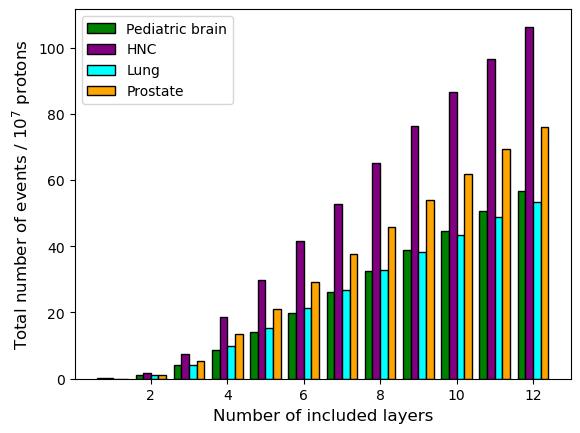

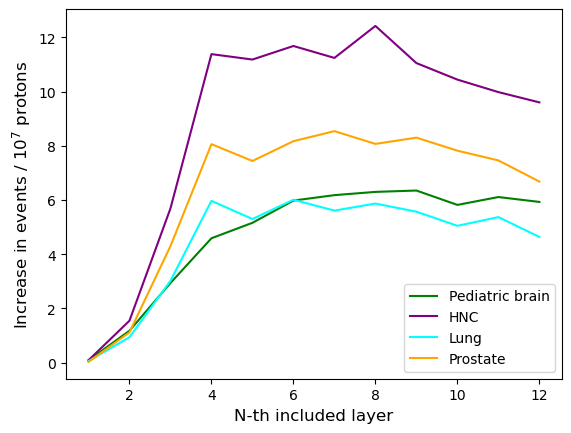

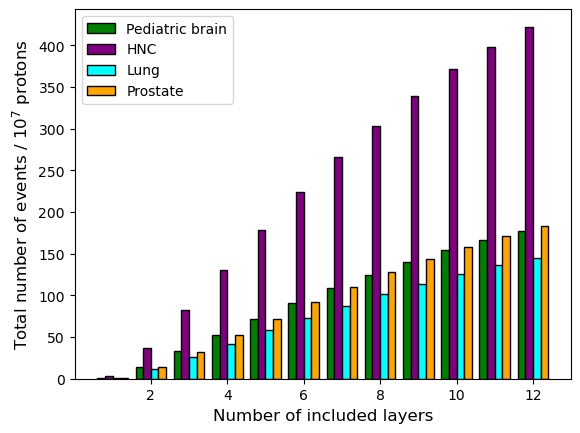

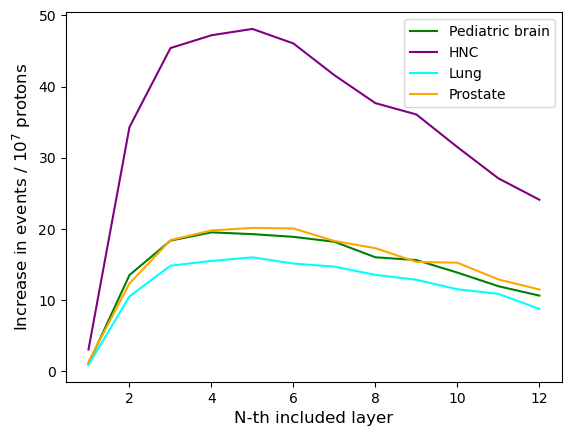

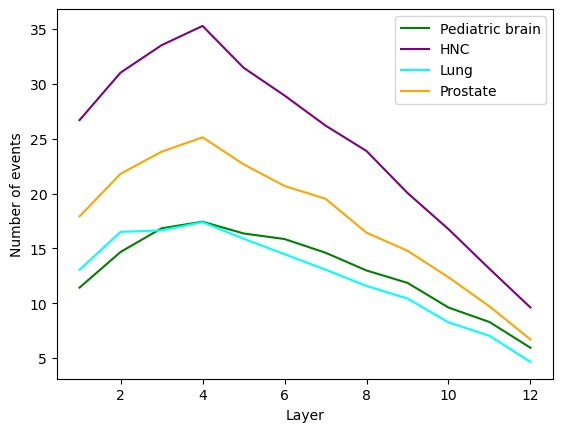

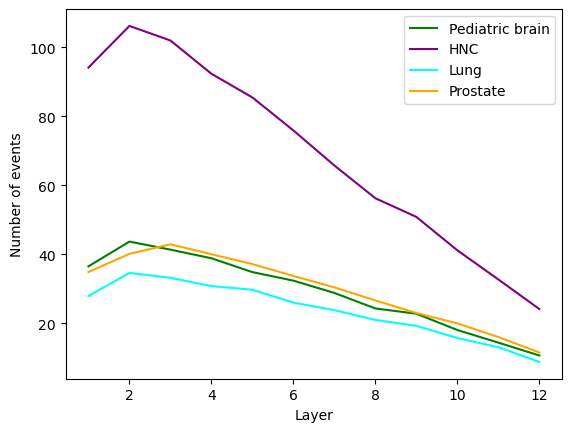

In [99]:
spot = "spot1"
layers = list(range(1, 13))

layers_brain = [i - 0.3 for i in layers]
layers_HNC = [i - 0.1 for i in layers]
layers_lung = [i + 0.1 for i in layers]
layers_prostate = [i + 0.3 for i in layers]

scaling = 1e2

brain_events, brain_new_events, brain_events_per_region = np.array(calc_event_layer_importance(patient="brain", spot=spot)) / scaling

HNC_events, HNC_new_events, HNC_events_per_region = np.array(calc_event_layer_importance(patient="HNC", spot=spot)) / scaling

lung_events, lung_new_events, lung_events_per_region = np.array(calc_event_layer_importance(patient="lung", spot=spot)) / scaling

prostate_events, prostate_new_events, prostate_events_per_region = np.array(calc_event_layer_importance(patient="prostate", spot=spot)) / scaling


# Figure(1, 1): Total number of events for X included layers: Gammas
fig1 = plt.figure(1)

plt.bar(layers_brain, brain_events[1], width=0.2, color="green", edgecolor="black", label="Pediatric brain")
plt.bar(layers_HNC, HNC_events[1], width=0.2, color="purple", edgecolor="black", label="HNC")
plt.bar(layers_lung, lung_events[1], width=0.2, color="cyan", edgecolor="black", label="Lung")
plt.bar(layers_prostate, prostate_events[1], width=0.2, color="orange", edgecolor="black", label="Prostate")

#plt.yscale("log")
plt.xlabel("Number of included layers", size=12)
plt.ylabel("Total number of events / $10^7$ protons", size=12)
plt.legend()


# Figure (1, 2): Number of new events by including a X-th layer: Gammas
fig2 = plt.figure(2)

plt.plot(layers, brain_new_events[1], color="green", label="Pediatric brain")
plt.plot(layers, HNC_new_events[1], color="purple", label="HNC")
plt.plot(layers, lung_new_events[1], color="cyan", label="Lung")
plt.plot(layers, prostate_new_events[1], color="orange", label="Prostate")

plt.xlabel("N-th included layer", size=12)
plt.ylabel("Increase in events / $10^7$ protons", size=12)
plt.legend()


# Figure(2, 1): Total number of events for X included layers: Neutrons
fig3 = plt.figure(3)

plt.bar(layers_brain, brain_events[2], width=0.2, color="green", edgecolor="black", label="Pediatric brain")
plt.bar(layers_HNC, HNC_events[2], width=0.2, color="purple", edgecolor="black", label="HNC")
plt.bar(layers_lung, lung_events[2], width=0.2, color="cyan", edgecolor="black", label="Lung")
plt.bar(layers_prostate, prostate_events[2], width=0.2, color="orange", edgecolor="black", label="Prostate")

#plt.yscale("log")
plt.xlabel("Number of included layers", size=12)
plt.ylabel("Total number of events / $10^7$ protons", size=12)
plt.legend()


# Figure (2, 2): Number of new events by including a X-th layer: Neutrons
fig4 = plt.figure(4)

plt.plot(layers, brain_new_events[2], color="green", label="Pediatric brain")
plt.plot(layers, HNC_new_events[2], color="purple", label="HNC")
plt.plot(layers, lung_new_events[2], color="cyan", label="Lung")
plt.plot(layers, prostate_new_events[2], color="orange", label="Prostate")

plt.xlabel("N-th included layer", size=12)
plt.ylabel("Increase in events / $10^7$ protons", size=12)
plt.legend()

#plt.yticks([0.5e-6 +  1.0e-6 * i for i in range(5)])


# Figure (1, 3): Number of events that depend on layer X: Gammas
fig5 = plt.figure(5)

plt.plot(layers, brain_events_per_region[1], color="green", label="Pediatric brain")
plt.plot(layers, HNC_events_per_region[1], color="purple", label="HNC")
plt.plot(layers, lung_events_per_region[1], color="cyan", label="Lung")
plt.plot(layers, prostate_events_per_region[1], color="orange", label="Prostate")

plt.xlabel("Layer")
plt.ylabel("Number of events")
plt.legend()


# Figure (1, 3): Number of events that depend on layer X: Neutrons
fig6 = plt.figure(6)

plt.plot(layers, brain_events_per_region[2], color="green", label="Pediatric brain")
plt.plot(layers, HNC_events_per_region[2], color="purple", label="HNC")
plt.plot(layers, lung_events_per_region[2], color="cyan", label="Lung")
plt.plot(layers, prostate_events_per_region[2], color="orange", label="Prostate")

plt.xlabel("Layer")
plt.ylabel("Number of events")
plt.legend()



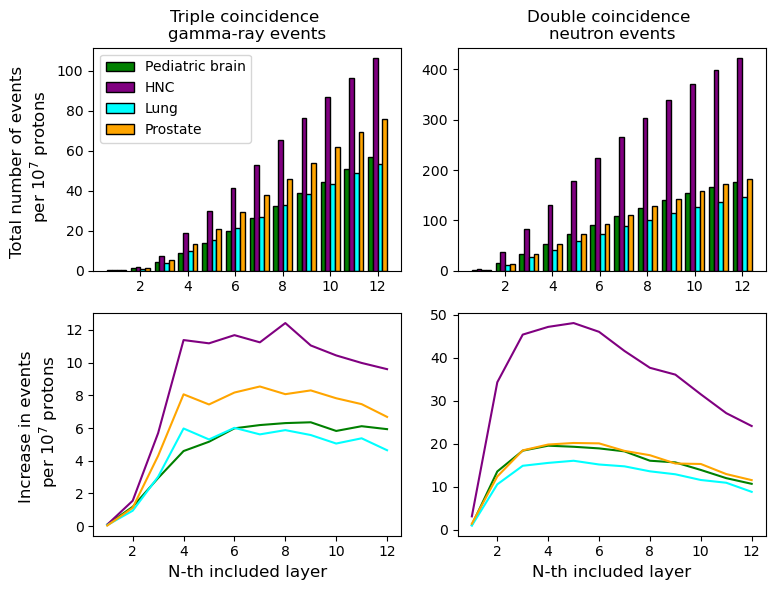

In [100]:
# Initializing figure
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

# Figure(1, 1): Total number of events for X included layers: Gammas
axs[0, 0].bar(layers_brain, brain_events[1], width=0.2, color="green", edgecolor="black", label="Pediatric brain")
axs[0, 0].bar(layers_HNC, HNC_events[1], width=0.2, color="purple", edgecolor="black", label="HNC")
axs[0, 0].bar(layers_lung, lung_events[1], width=0.2, color="cyan", edgecolor="black", label="Lung")
axs[0, 0].bar(layers_prostate, prostate_events[1], width=0.2, color="orange", edgecolor="black", label="Prostate")

axs[0, 0].set_ylabel("Total number of events \n per $10^7$ protons", size=12)
axs[0, 0].legend()
axs[0, 0].set_title("Triple coincidence \ngamma-ray events")


# Figure (1, 2): Number of new events by including a X-th layer: Gammas
axs[1, 0].plot(layers, brain_new_events[1], color="green", label="Pediatric brain")
axs[1, 0].plot(layers, HNC_new_events[1], color="purple", label="HNC")
axs[1, 0].plot(layers, lung_new_events[1], color="cyan", label="Lung")
axs[1, 0].plot(layers, prostate_new_events[1], color="orange", label="Prostate")

axs[1, 0].set_xlabel("N-th included layer", size=12)
axs[1, 0].set_ylabel("Increase in events \n per $10^7$ protons", size=12)



# Figure(2, 1): Total number of events for X included layers: Neutrons
axs[0, 1].bar(layers_brain, brain_events[2], width=0.2, color="green", edgecolor="black", label="Pediatric brain")
axs[0, 1].bar(layers_HNC, HNC_events[2], width=0.2, color="purple", edgecolor="black", label="HNC")
axs[0, 1].bar(layers_lung, lung_events[2], width=0.2, color="cyan", edgecolor="black", label="Lung")
axs[0, 1].bar(layers_prostate, prostate_events[2], width=0.2, color="orange", edgecolor="black", label="Prostate")

axs[0, 1].set_title("Double coincidence \nneutron events")


# Figure (2, 2): Number of new events by including a X-th layer: Neutrons
axs[1, 1].plot(layers, brain_new_events[2], color="green", label="Pediatric brain")
axs[1, 1].plot(layers, HNC_new_events[2], color="purple", label="HNC")
axs[1, 1].plot(layers, lung_new_events[2], color="cyan", label="Lung")
axs[1, 1].plot(layers, prostate_new_events[2], color="orange", label="Prostate")

axs[1, 1].set_xlabel("N-th included layer", size=12)

plt.tight_layout()

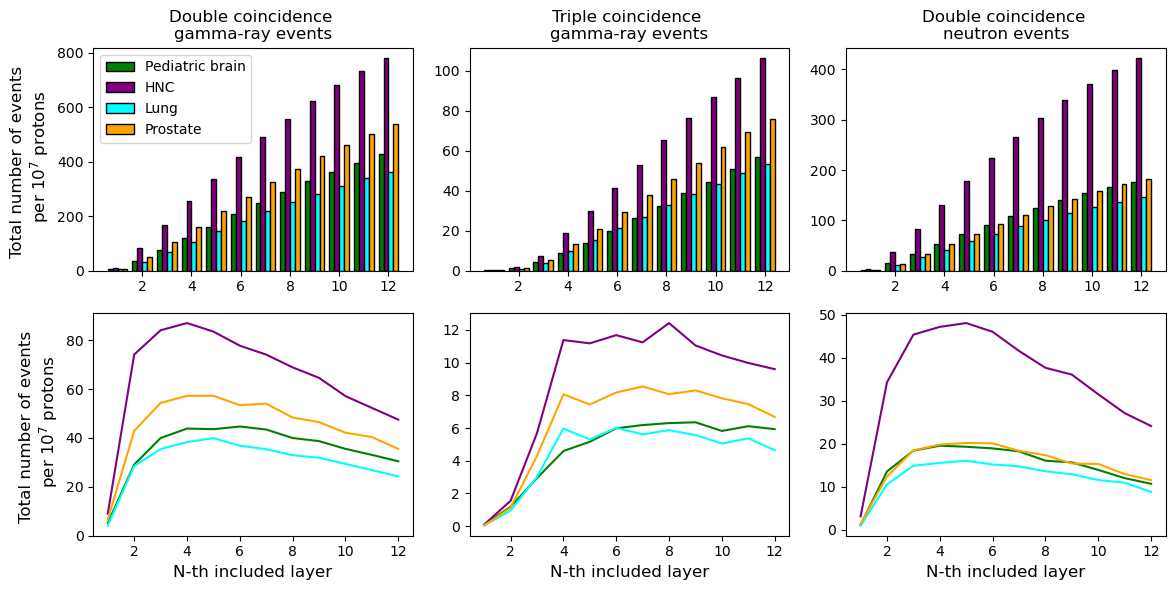

In [ ]:
# Initializing figure
fig, axs = plt.subplots(2, 3, figsize=(12, 6))


# Figure(0, 0): Total number of events for X included layers: Double gammas
axs[0, 0].bar(layers_brain, brain_events[0], width=0.2, color="green", edgecolor="black", label="Pediatric brain")
axs[0, 0].bar(layers_HNC, HNC_events[0], width=0.2, color="purple", edgecolor="black", label="HNC")
axs[0, 0].bar(layers_lung, lung_events[0], width=0.2, color="cyan", edgecolor="black", label="Lung")
axs[0, 0].bar(layers_prostate, prostate_events[0], width=0.2, color="orange", edgecolor="black", label="Prostate")

axs[0, 0].legend()
axs[0, 0].set_ylabel("Total number of events \n per $10^7$ protons", size=12)
axs[0, 0].set_title("Double coincidence \ngamma-ray events")


# Figure(1, 0): Number of new events by including an X-th layer: Double gammas
axs[1, 0].plot(layers, brain_new_events[0], color="green", label="Pediatric brain")
axs[1, 0].plot(layers, HNC_new_events[0], color="purple", label="HNC")
axs[1, 0].plot(layers, lung_new_events[0], color="cyan", label="Lung")
axs[1, 0].plot(layers, prostate_new_events[0], color="orange", label="Prostate")

axs[1, 0].set_xlabel("N-th included layer", size=12)
axs[1, 0].set_ylabel("Total number of events \n per $10^7$ protons", size=12)


# Figure(0, 1): Total number of events for X included layers: Triple gammas
axs[0, 1].bar(layers_brain, brain_events[1], width=0.2, color="green", edgecolor="black", label=f"")
axs[0, 1].bar(layers_HNC, HNC_events[1], width=0.2, color="purple", edgecolor="black", label=f"")
axs[0, 1].bar(layers_lung, lung_events[1], width=0.2, color="cyan", edgecolor="black", label=f"")
axs[0, 1].bar(layers_prostate, prostate_events[1], width=0.2, color="orange", edgecolor="black", label=f"")

axs[0, 1].set_title("Triple coincidence \ngamma-ray events")


# Figure (1, 1): Number of new events by including a X-th layer: Triple gammas
axs[1, 1].plot(layers, brain_new_events[1], color="green", label="Pediatric brain")
axs[1, 1].plot(layers, HNC_new_events[1], color="purple", label="HNC")
axs[1, 1].plot(layers, lung_new_events[1], color="cyan", label="Lung")
axs[1, 1].plot(layers, prostate_new_events[1], color="orange", label="Prostate")

axs[1, 1].set_xlabel("N-th included layer", size=12)


# Figure(0, 2): Total number of events for X included layers: Neutrons
axs[0, 2].bar(layers_brain, brain_events[2], width=0.2, color="green", edgecolor="black", label="Pediatric brain")
axs[0, 2].bar(layers_HNC, HNC_events[2], width=0.2, color="purple", edgecolor="black", label="HNC")
axs[0, 2].bar(layers_lung, lung_events[2], width=0.2, color="cyan", edgecolor="black", label="Lung")
axs[0, 2].bar(layers_prostate, prostate_events[2], width=0.2, color="orange", edgecolor="black", label="Prostate")

axs[0, 2].set_title("Double coincidence \nneutron events")


# Figure (1, 2): Number of new events by including a X-th layer: Neutrons
axs[1, 2].plot(layers, brain_new_events[2], color="green", label="Pediatric brain")
axs[1, 2].plot(layers, HNC_new_events[2], color="purple", label="HNC")
axs[1, 2].plot(layers, lung_new_events[2], color="cyan", label="Lung")
axs[1, 2].plot(layers, prostate_new_events[2], color="orange", label="Prostate")

axs[1, 2].set_xlabel("N-th included layer", size=12)

plt.tight_layout()

Energy specter of photon/neutron before scattering

In [12]:
# Gammas
gamma_Es = [] # np.array([[1, 2, 3], [3, 2, 9], [30, 34, 38], ..., [1, 2, 3]])

gamma_events, neutron_events = both_events["brain"]["spot1"]

for event in gamma_events:
    E1 = event[0][8]
    E2 = event[1][8]
    E3 = event[2][8]

    gamma_Es.append([E1, E2, E3])

gamma_Es = np.array(gamma_Es)
gamma_events = None # Remove variable from memory



# Neutrons
neutron_Es = [] # np.array([[1, 2], [3, 2], [30, 34], ..., [1, 3]])

for event in neutron_events:
    E1 = event[0][8]
    E2 = event[1][8]

    neutron_Es.append([E1, E2])

neutron_Es = np.array(neutron_Es)
neutron_events = None   # Remove variable from memory

Text(0, 0.5, 'Counts')

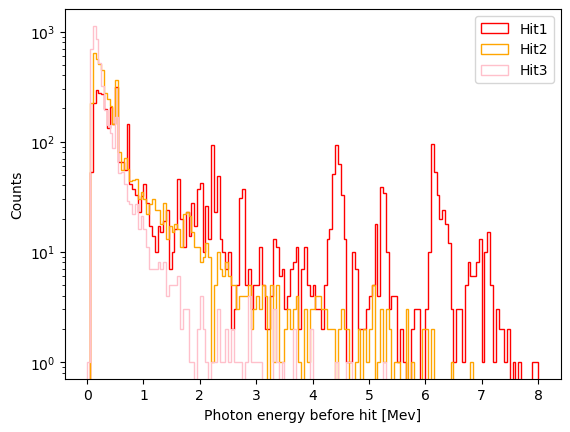

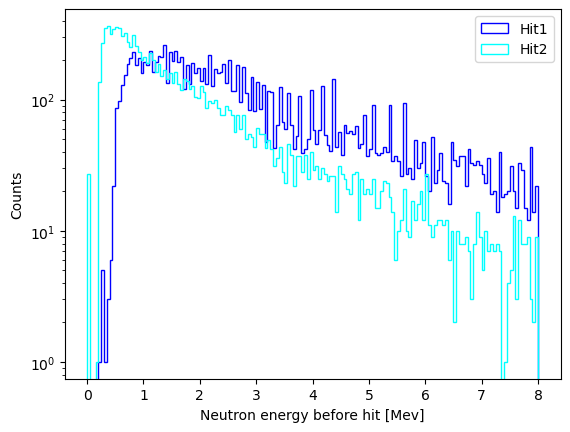

In [13]:
# Gammas
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]


plt.hist(gamma_Es[:, 0], bins=bins, histtype="step", label="Hit1", color="red")
plt.hist(gamma_Es[:, 1], bins=bins, histtype="step", label="Hit2", color="orange")
plt.hist(gamma_Es[:, 2], bins=bins, histtype="step", label="Hit3", color="pink")

plt.yscale("log")
plt.legend()

plt.xlabel("Photon energy before hit [Mev]")
plt.ylabel("Counts")


# Neutrons
bin_width = 0.05     # MeV
max_energy = 8   # MeV
bins = np.arange(0.0, max_energy + bin_width, bin_width)    # Bins: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, ..., ]

plt.figure()


plt.hist(neutron_Es[:, 0], bins=bins, histtype="step", label="Hit1", color="blue")
plt.hist(neutron_Es[:, 1], bins=bins, histtype="step", label="Hit2", color="cyan")

plt.yscale("log")
plt.legend()

plt.xlabel("Neutron energy before hit [Mev]")
plt.ylabel("Counts")
